In [72]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [38]:
# Define column names: static columns + dynamically generated Payload columns
column_names = ["Time_Offset", "CAN_ID", "DLC"] + [f'Payload_{i+1}' for i in range(32)] + ["Label"]

# Read the CSV files with the specified column names
CANFD_Flooding = pd.read_csv("CANFD_Flooding.csv", names=column_names)
CANFD_Fuzzing = pd.read_csv("CANFD_Fuzzing.csv", names=column_names)
CANFD_Malfunction = pd.read_csv("CANFD_Malfunction.csv", names=column_names)


/tmp/ipykernel_40348/1446610945.py:5: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  CANFD_Flooding = pd.read_csv("CANFD_Flooding.csv", names=column_names)
/tmp/ipykernel_40348/1446610945.py:6: DtypeWarning: Columns (22,29,31,32,34) have mixed types. Specify dtype option on import or set low_memory=False.
  CANFD_Fuzzing = pd.read_csv("CANFD_Fuzzing.csv", names=column_names)
/tmp/ipykernel_40348/1446610945.py:7: DtypeWarning: Columns (29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  CANFD_Malfunction = pd.read_csv("CANFD_Malfunction.csv", names=column_names)


In [39]:
CANFD_Flooding

,Time_Offset,CAN_ID,DLC,Payload_1,Payload_2,Payload_3,Payload_4,Payload_5,Payload_6,Payload_7,...,Payload_24,Payload_25,Payload_26,Payload_27,Payload_28,Payload_29,Payload_30,Payload_31,Payload_32,Label
0,1307.00281,004A,32,1C,8C,DC,00,00,00,02,...,00,00,00,00,00,00,0.0,00,0.0,R
1,1307.00295,0155,16,DD,7E,DC,13,00,00,00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1307.00314,0165,24,84,ED,E9,08,00,00,00,...,00,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1307.00337,016A,32,79,46,E9,00,01,00,00,...,00,00,00,00,00,00,0.0,00,0.0,R
4,1307.00352,0170,16,59,57,E9,03,00,00,00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2784301,2028.99681,0145,32,F5,13,F0,10,01,05,04,...,00,00,00,00,00,00,0.0,00,0.0,R
2784302,2028.99744,007A,24,0A,F3,FC,8E,8E,8E,8E,...,00,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2784303,2028.99763,00A5,24,F7,42,FC,FD,E1,1F,FB,...,00,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2784304,2028.99825,0065,24,F2,39,F6,00,00,EE,FF,...,00,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
CANFD_Flooding["Payload_25"][2]

'R'

In [49]:
def update_label_based_on_dlc(df):
    for i in range(len(df)):
        if df.DLC[i] != 32:  # Ensure we check if DLC is 32
            a = df.DLC[i]
            out = df[f'Payload_{a+1}'][i]  # Dynamically access the correct Payload column
            df.at[i, "Label"] = out  # Correctly assign the value to the Label column
    return df

In [52]:
CANFD_Flood = update_label_based_on_dlc(CANFD_Flooding)

In [58]:
CANFD_Flood["Time_Gap"] = CANFD_Flood['Time_Offset'].diff(1)

In [54]:
pd.value_counts(CANFD_Flood["Label"])

/tmp/ipykernel_40348/2861260845.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(CANFD_Flood["Label"])


Label
R    1796065
T     988241
Name: count, dtype: int64

In [60]:
CANFD_Flood = CANFD_Flood[["Time_Offset", "CAN_ID", "DLC", "Time_Gap", "Label"]]
CANFD_Flood

,Time_Offset,CAN_ID,DLC,Time_Gap,Label
0,1307.00281,004A,32,NaN,R
1,1307.00295,0155,16,0.00014,R
2,1307.00314,0165,24,0.00019,R
3,1307.00337,016A,32,0.00023,R
4,1307.00352,0170,16,0.00015,R
...,...,...,...,...,...
2784301,2028.99681,0145,32,0.00106,R
2784302,2028.99744,007A,24,0.00063,R
2784303,2028.99763,00A5,24,0.00019,R
2784304,2028.99825,0065,24,0.00062,R


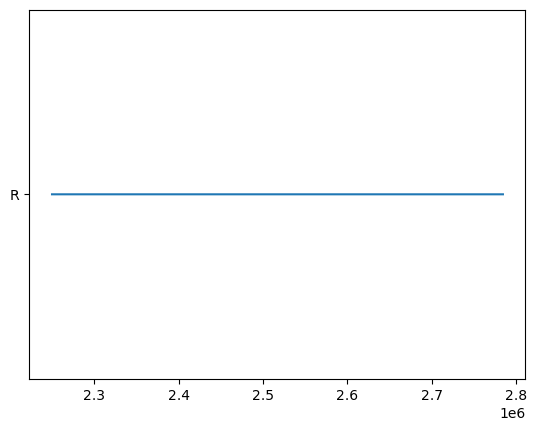

In [82]:
plt.plot(CANFD_Flood[2250000:]["Label"])

In [83]:
CANFD_Normal_1 = CANFD_Flood[2250000:]

In [61]:
CANFD_Fuzz = update_label_based_on_dlc(CANFD_Fuzzing)

In [62]:
CANFD_Fuzz["Time_Gap"] = CANFD_Fuzz['Time_Offset'].diff(1)

In [65]:
pd.value_counts(CANFD_Fuzz["Label"])

/tmp/ipykernel_40348/1130627449.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(CANFD_Fuzz["Label"])


Label
R    1895836
T     506506
Name: count, dtype: int64

In [64]:
CANFD_Fuzz = CANFD_Fuzz[["Time_Offset", "CAN_ID", "DLC", "Time_Gap", "Label"]]
CANFD_Fuzz

,Time_Offset,CAN_ID,DLC,Time_Gap,Label
0,2830.00005,004A,32,NaN,R
1,2830.00024,0175,24,0.00019,R
2,2830.00035,006F,8,0.00011,R
3,2830.00050,01E5,16,0.00015,R
4,2830.00065,020A,16,0.00015,R
...,...,...,...,...,...
2402337,3580.99638,0419,8,0.00011,R
2402338,3580.99729,0040,32,0.00091,R
2402339,3580.99752,006A,32,0.00023,R
2402340,3580.99929,00B5,32,0.00177,R


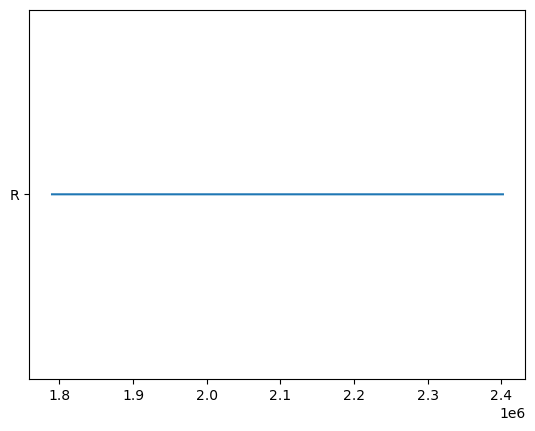

In [87]:
plt.plot(CANFD_Fuzz[1790000:]["Label"])

In [88]:
CANFD_Normal_2 = CANFD_Flood[2250000:]

In [66]:
CANFD_Mal = update_label_based_on_dlc(CANFD_Malfunction)

In [67]:
CANFD_Mal["Time_Gap"] = CANFD_Mal['Time_Offset'].diff(1)

In [70]:
pd.value_counts(CANFD_Mal["Label"])

/tmp/ipykernel_40348/3924990162.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(CANFD_Mal["Label"])


Label
R    1798223
T     135726
Name: count, dtype: int64

In [69]:
CANFD_Mal = CANFD_Mal[["Time_Offset", "CAN_ID", "DLC", "Time_Gap", "Label"]]
CANFD_Mal

,Time_Offset,CAN_ID,DLC,Time_Gap,Label
0,3581.00035,0260,32,NaN,R
1,3581.00089,0060,32,0.00054,R
2,3581.00108,00B0,24,0.00019,R
3,3581.00130,004A,32,0.00022,R
4,3581.00145,0125,16,0.00015,R
...,...,...,...,...,...
1933944,4294.96627,016A,32,0.00032,R
1933945,4294.96646,00A0,24,0.00019,R
1933946,4294.96665,0165,24,0.00019,R
1933947,4294.96680,0170,16,0.00015,R


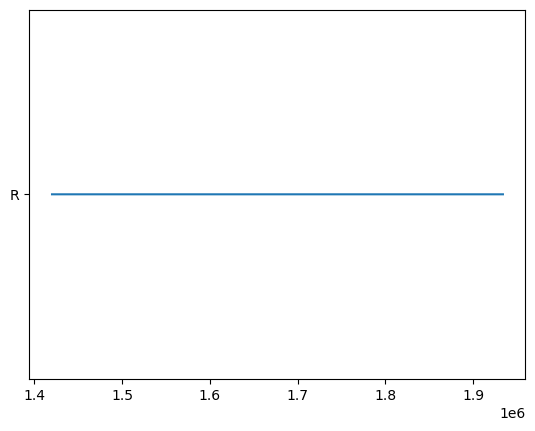

In [91]:
plt.plot(CANFD_Mal[1420000:]["Label"])

In [92]:
CANFD_Normal_3 = CANFD_Flood[1420000:]

In [99]:
CANFD_Normal = pd.concat([CANFD_Flood[2250000:], CANFD_Fuzz[1790000:], CANFD_Mal[1420000:]])

In [100]:
pd.value_counts(CANFD_Normal['Label'])

/tmp/ipykernel_40348/300746130.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(CANFD_Normal['Label'])


Label
R    1660597
Name: count, dtype: int64

In [101]:
CANFD_Normal.to_csv('CANFD_Normal.csv', index=False)

In [102]:
# Save the DataFrame to a CSV file
CANFD_Flood[:2250000].to_csv('CANFD_Flood.csv', index=False)
# Save the DataFrame to a CSV file
CANFD_Fuzz[:1790000].to_csv('CANFD_Fuzz.csv', index=False)
# Save the DataFrame to a CSV file
CANFD_Mal[:1420000].to_csv('CANFD_Mal.csv', index=False)

In [104]:
pd.value_counts(CANFD_Flood[:2250000]['Label'])

/tmp/ipykernel_40348/3796124600.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(CANFD_Flood[:2250000]['Label'])


Label
R    1261759
T     988241
Name: count, dtype: int64

In [105]:
pd.value_counts(CANFD_Fuzz[:2250000]['Label'])

/tmp/ipykernel_40348/3600777978.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(CANFD_Fuzz[:2250000]['Label'])


Label
R    1743494
T     506506
Name: count, dtype: int64

In [106]:
pd.value_counts(CANFD_Mal[:2250000]['Label'])

/tmp/ipykernel_40348/2662140437.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(CANFD_Mal[:2250000]['Label'])


Label
R    1798223
T     135726
Name: count, dtype: int64